<a href="https://colab.research.google.com/github/rainforest01-coder/ESAA_files/blob/OB/week10_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 7.5 LSTM
RNN은 결정적 단점이 있습니다. 앞서 언급했듯이 가중치가 업데이트되는 과정에서 기울기가 1보
다 작은 값이 계속 곱해지기 때문에 기울기가 사라지는 기울기 소멸 문제가 발생합니다. 이를 해
결하기 위해 LSTM이나 GRU 같은 확장된 RNN 방식들을 사용하고 있습니다.

## 7.5.1 LSTM 구조
* LSTM 순전파  
LSTM은 기울기 소멸 문제를 해결하기 위해 망각 게이트 입력 게이트 출력 게이트라는 새로운
요소를 은닉층의 각 뉴런에 추가

-망각 게이트  
 과거 정보와 현재 데이터
를 입력받아 시그모이드를 취한 후 그 값을 과거 정보에 곱해 줍니다. 따라서 시그모이드의 출력
이 0이면 과거 정보는 버리고 1이면 과거 정보는 온전히 보존합니다.
0과 1 사이의 출력 값을 가지는 ht-1과 Xf를 입력 값으로 받습니다. 이때 Xf는 새로운 입력 값이고
ht-1은 이전 은닉층에서 입력되는 값입니다. 즉， ht-1과Xf를 이용하여 이전 상태 정보를 현재 메모
리에 반영할지 결정하는 역할을합니다.
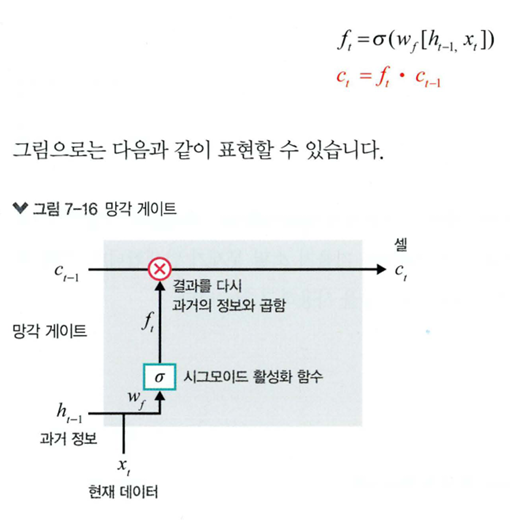


-입력게이트
입력 게이트(input gatc)는 현재 정보를 기억하기 위해 만들어졌습니다. 과거 정보와 현재 데이터
를 입력받아 시그모이드와 하이퍼볼력 탄젠트 함수를 기반으로 현재 정보에 대한 보존량을 결정합니다.

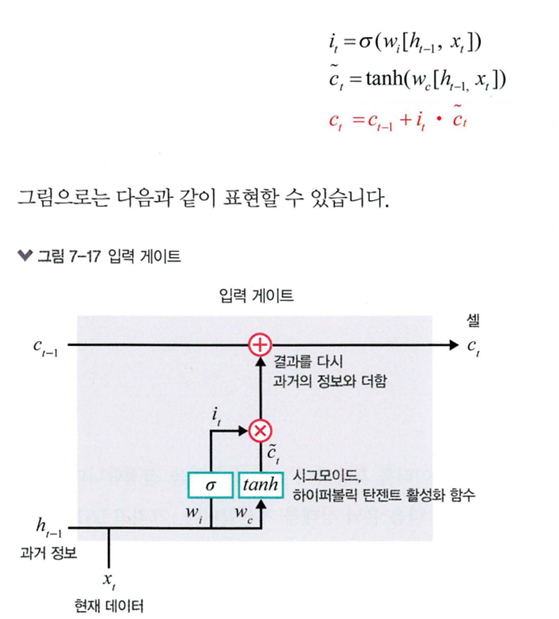

-셀
각 단계에 대한 은닉 노드(hidclen nodc)를 메모리 셀이라고 합니다. ‘총합(sum)’을 사용하여 셀 값
을 반영하며， 이것으로 기울기 소멸 문제가 해결됩니다.
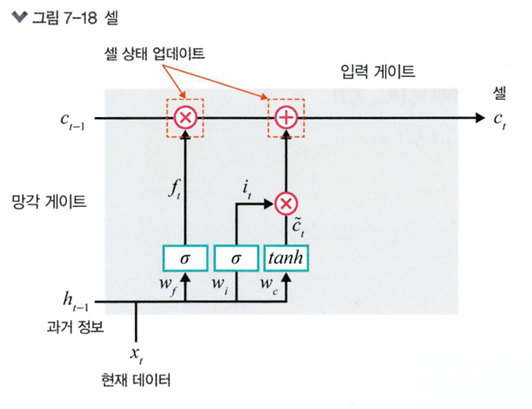

-출력게이트

 과거 정보와 현재 데이터를 시용하여 뉴런의 출력을 결정합니다. 이전
은닉 상태(hidden statc)와 t번째 입력을 고려해서 다음 은닉 상태를 계산합니다. 그리고 LSTM에서
는 이 은닉 상태가 그 시점에서의 출력이 됩니다.
출력 게이트는 갱신된 메모리의 출력 값을 제어하는 역할을 합니다.    
• 계산한값이 1이면의미 있는결과로최종출력   
• 계산한 값이 0이면 해당 연산 출력을 하지 않음  

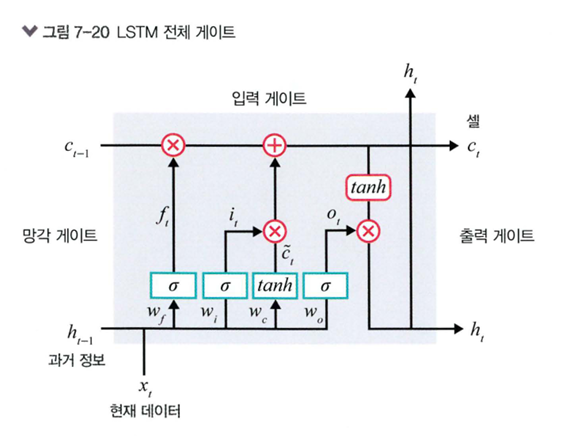

-LSTM 역전파

LSTM은 셀을 통해서 역전파를 수행하기 때문에 ‘중단 없는 기울기라
고도합니다.

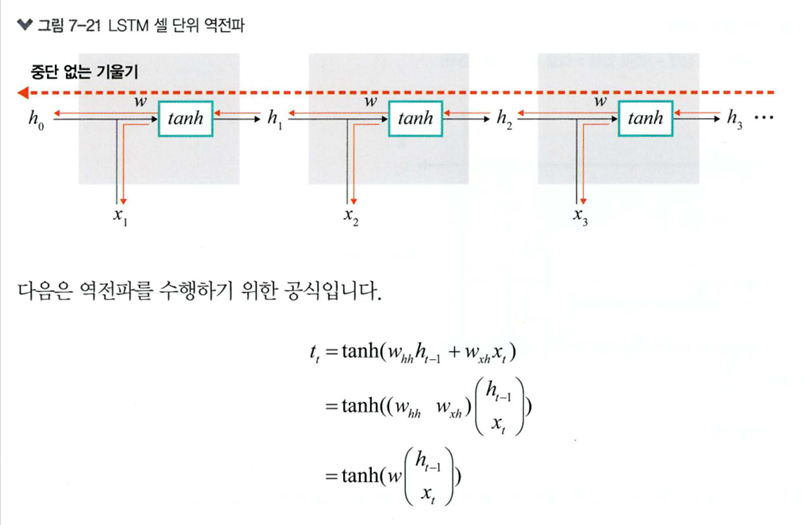

## 7.5.2 LSTM 셀 구현



In [2]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as dataset
from torch.autograd import Variable
from torch.nn import Parameter
from torch import Tensor
import torch.nn.functional as F
from torch.utils.data import DataLoader
import math

device=torch.device('cuda:0'if torch.cuda.is_available() else 'cpu')
cuda=True if torch.cuda.is_available() else False

Tensor=torch.cuda.FloatTensor if cuda else torch.FloatTensor

torch.manual_seed(125)
if torch.cuda.is_available():
  torch.cuda.manual_seed_all(125)

In [3]:
import torchvision.transforms as transforms

mnist_transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,),(1.0,))
])

In [4]:
from torchvision.datasets import MNIST

download_root='/content/data'
train_dataset=MNIST(download_root, transform=mnist_transform,train=True,
                    download=True)
valid_dataset=MNIST(download_root, transform=mnist_transform,train=False,
                    download=True)
test_dataset=MNIST(download_root, transform=mnist_transform,train=False,
                    download=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 484kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.93MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.28MB/s]


@ 첫 번째 파라미터: MNIST를 내려받을 위치 지정
@ transform: 앞에서 정의했던 데이터 전처리 적용
@
@ train: True로 설정할 경우 훈련용 데이터셋을 가져오지만 False로 설정할 경우 테스트용
데이터셋을 가져옵니다.
@ download: True로 설정될 경우 내려받으려는 위치에 MNIST 파일이 없으면 내려받지만 파
일이 있다면 내려받지 않습니다.

In [5]:
batch_size=64
train_loader=DataLoader(dataset=train_dataset,
                        batch_size=batch_size,
                        shuffle=True)
valid_loader=DataLoader(dataset=valid_dataset,
                        batch_size=batch_size,
                        shuffle=True)
test_loader=DataLoader(dataset=test_dataset,
                       batch_size=batch_size,
                       shuffle=True)

In [6]:
batch_size=100
n_iters=6000
num_epochs=n_iters/(len(train_dataset)/batch_size)
num_epochs=int(num_epochs)

In [7]:
class LSTMCell(nn.Module):
  def __init__(self,input_size,hidden_size,bias=True):
    super(LSTMCell,self).__init__()
    self.input_size=input_size
    self.hidden_size=hidden_size
    self.bias=bias
    self.x2h=nn.Linear(input_size,4*hidden_size,bias=bias)
    self.h2h=nn.Linear(hidden_size,4*hidden_size,bias=bias)
    self.reset_parameters()
  def reset_parameters(self):
    std=1.0/math.sqrt(self.hidden_size)
    for w in self.parameters():
      w.data.uniform_(-std,std)# 난수 생성->모델 파라미터 초기화
  def forward(self,x,hidden):
    hx,cx=hidden
    x=x.view(-1,x.size(1))
    gates=self.x2h(x)+self.h2h(hx)
    gates=gates.squeeze()
    ingate,forgetgate,cellgate,outgate=gates.chunk(4,1)
    ingate=F.sigmoid(ingate)
    forgetgate=F.sigmoid(ingate)
    cellgate=F.tanh(cellgate)
    outgate=F.sigmoid(outgate)
    cy=torch.mul(cx,forgetgate)+torch.mul(ingate,cellgate)
    hy=torch.mul(outgate,F.tanh(cy))
    return(hy,cy)



In [8]:
class LSTMModel(nn.Module):
  def __init__(self,input_dim,hidden_dim,layer_dim,output_dim,bias=True):
    super(LSTMModel,self).__init__()
    self.hidden_dim=hidden_dim
    self.layer_dim=layer_dim
    self.lstm=LSTMCell(input_dim,hidden_dim,layer_dim)
    self.fc=nn.Linear(hidden_dim,output_dim)
  def forward(self,x):
    if torch.cuda.is_available():
      h0=Variable(torch.zeros(self.layer_dim,x.size(0),self.hidden_dim).cuda())
    else:
      h0=Variable(torch.zeros(self.layer_dim,x.size(0),self.hidden_dim))
    if torch.cuda.is_available():
      c0=Variable(torch.zeros(self.layer_dim,x.size(0),self.hidden_dim).cuda())
    else:
      c0=Variable(torch.zeros(self.layer_dim,x.size(0),self.hidden_dim))
    outs=[]
    cn=c0[0,:,:]
    hn=h0[0,:,:]

    for seq in range(x.size(1)):
      hn,cn=self.lstm(x[:,seq,:],(hn,cn))
      outs.append(hn)
    out=outs[-1].squeeze()
    out=self.fc(out)
    return out



In [9]:
input_dim=28
hidden_dim=128
layer_dim=1
output_dim=10

model=LSTMModel(input_dim,hidden_dim,layer_dim,output_dim)
if torch.cuda.is_available():
  model.cuda()
criterion=nn.CrossEntropyLoss()
learning_rate=0.1
optimizer=torch.optim.SGD(model.parameters(),lr=learning_rate)

In [12]:
seq_dim=28
loss_list=[]
iter=0
for epoch in range(num_epochs):
  for i, (images,labels)  in enumerate(train_loader):
    if torch.cuda.is_available():
      images=Variable(images.view(-1,seq_dim,input_dim).cuda())
      labels=Variable(labels.cuda())
    else:
      images=Variable(images.view(-1,seq_dim,input_dim))
      labels=Variable(labels)
    optimizer.zero_grad()
    outputs=model(images)
    loss=criterion(outputs,labels)
    if torch.cuda.is_available():
      loss.cuda()
    loss.backward()
    optimizer.step()
    loss_list.append(loss.item())
    iter+=1
    if iter%500==0:
      correct=0
      total=0
      for images,labels in valid_loader:
        if torch.cuda.is_available():
          images=Variable(images.view(-1,seq_dim,input_dim).cuda())
        else:
          images=Variable(images.view(-1,seq_dim,input_dim))
        outputs=model(images)
        _,predicted=torch.max(outputs.data,1)
        total+=labels.size(0)
        if torch.cuda.is_available():
          correct+=(predicted.cpu()==labels.cpu()).sum()
        else:
          correct+=(predicted==labels).sum()
      accuracy=100*correct/total
      print('Iteration: {}. Loss: {}. Accuracy: {}'.format(iter,loss.item(),accuracy))


Iteration: 500. Loss: 1.052736759185791. Accuracy: 54.970001220703125
Iteration: 1000. Loss: 0.5082352161407471. Accuracy: 83.77999877929688
Iteration: 1500. Loss: 0.24242012202739716. Accuracy: 92.30999755859375
Iteration: 2000. Loss: 0.1733570247888565. Accuracy: 93.70999908447266
Iteration: 2500. Loss: 0.07329228520393372. Accuracy: 95.25
Iteration: 3000. Loss: 0.06368519365787506. Accuracy: 95.58999633789062
Iteration: 3500. Loss: 0.08808538317680359. Accuracy: 96.55999755859375
Iteration: 4000. Loss: 0.04286644235253334. Accuracy: 96.58000183105469
Iteration: 4500. Loss: 0.09422267973423004. Accuracy: 97.0199966430664
Iteration: 5000. Loss: 0.08609188348054886. Accuracy: 97.31999969482422
Iteration: 5500. Loss: 0.1675228774547577. Accuracy: 97.16999816894531
Iteration: 6000. Loss: 0.044026631861925125. Accuracy: 97.30000305175781
Iteration: 6500. Loss: 0.08360026776790619. Accuracy: 97.44999694824219
Iteration: 7000. Loss: 0.012562297284603119. Accuracy: 97.47000122070312
Iteratio

In [15]:
def evaluate(model,val_iter):
  corrects,total,total_loss=0,0,0
  model.eval()
  for images,labels in val_iter:
    if torch.cuda.is_available():
      images=Variable(images.view(-1,seq_dim,input_dim).cuda())
      labels = labels.cuda()
    else:
      images=Variable(images.view(-1,seq_dim,input_dim).to(device))
      labels = labels.to(device)
    logit=model(images).to(device)
    loss=F.cross_entropy(logit,labels,reduction='sum')
    _,predicted=torch.max(logit.data,1)
    total+=labels.size(0)
    total_loss+=loss.item()
    corrects+=(predicted==labels).sum()
  avg_loss=total_loss/len(val_iter.dataset)
  avg_accuracy=corrects/total
  return avg_loss,avg_accuracy

In [16]:
test_loss,test_acc=evaluate(model,test_loader)
print('Test Loss: %5.2f | Test Accuracy: %5.2f'%(test_loss,test_acc))

Test Loss:  0.06 | Test Accuracy:  0.98


## 7.5.3 LSTM 계층 구현

In [17]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset,DataLoader
from torch.autograd import Variable
from tqdm import tqdm_notebook
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.model_selection import train_test_split
device=torch.device('cuda:0' if torch.cuda.is_available( ) else 'cpu')

In [23]:
data=pd.read_csv('SBUX.csv')
print(data.dtypes)

Date          object
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object


In [25]:
data['Date']=pd.to_datetime(data['Date'])
data.set_index('Date',inplace=True)

In [26]:
data['Volume']=data['Volume'].astype(float)

In [27]:
X=data.iloc[:,:-1]
y=data.iloc[:,5:6]
print(X)
print(y)

                  Open        High         Low       Close   Adj Close
Date                                                                  
2019-12-11   86.260002   86.870003   85.849998   86.589996   84.145752
2019-12-12   88.000000   88.889999   87.540001   88.209999   85.720032
2019-12-13   88.019997   88.790001   87.580002   88.669998   86.167046
2019-12-16   89.139999   89.300003   88.430000   88.779999   86.273941
2019-12-17   88.870003   88.970001   87.470001   88.129997   85.642288
...                ...         ...         ...         ...         ...
2020-12-04  101.349998  102.940002  101.070000  102.279999  101.442787
2020-12-07  102.010002  102.220001  100.690002  101.410004  100.579918
2020-12-08  100.370003  101.570000  100.010002  101.209999  100.381554
2020-12-09  101.940002  102.209999  100.099998  100.400002   99.578186
2020-12-10  103.510002  106.089996  102.750000  105.389999  104.527336

[253 rows x 5 columns]
                Volume
Date                  
2019-12

 MinMaxScaler()와 StandardScaler()를 사용하여 분산을 조정

In [28]:
ms=MinMaxScaler()
ss=StandardScaler()
X_ss=ss.fit_transform(X)
y_ms=ms.fit_transform(y)
X_train=X_ss[:200,:]
X_test=X_ss[200:,:]

y_train=y_ms[:200,:]
y_test=y_ms[200:,:]

print('Training Shape',X_train.shape,y_train.shape)
print('Testing Shape',X_test.shape,y_test.shape)

Training Shape (200, 5) (200, 1)
Testing Shape (53, 5) (53, 1)


In [29]:
X_train_tensors=Variable(torch.Tensor(X_train))
X_test_tensors=Variable(torch.Tensor(X_test))

y_train_tensors=Variable(torch.Tensor(y_train))
y_test_tensors=Variable(torch.Tensor(y_test))

X_train_tensors_f=torch.reshape(X_train_tensors,(X_train_tensors.shape[0],
                                                 1, X_train_tensors.shape[1]))
X_test_tensors_f=torch.reshape(X_test_tensors,(X_test_tensors.shape[0],
                                                 1, X_test_tensors.shape[1]))
print('Training Shape',X_train_tensors_f.shape,y_train_tensors.shape)
print('Testing Shape',X_test_tensors_f.shape,y_test_tensors.shape)

Training Shape torch.Size([200, 1, 5]) torch.Size([200, 1])
Testing Shape torch.Size([53, 1, 5]) torch.Size([53, 1])


In [34]:
class LSTM(nn.Module):
  def __init__(self,num_classes,input_size,hidden_size,num_layers,seq_length):
    super(LSTM,self).__init__()
    self.num_classes=num_classes
    self.num_layers=num_layers
    self.input_size=input_size
    self.hidden_size=hidden_size
    self.seq_lingth=seq_length

    self.lstm=nn.LSTM(input_size=input_size,hidden_size=hidden_size,
                      num_layers=num_layers,batch_first=True)
    self.fc_1=nn.Linear(hidden_size,128)
    self.fc=nn.Linear(128,num_classes)
    self.relu=nn.ReLU()
  def forward(self,x):
    h_0=Variable(torch.zeros(self.num_layers,x.size(0),self.hidden_size))
    c_0=Variable(torch.zeros(self.num_layers,x.size(0),self.hidden_size))
    output,(hn,cn)=self.lstm(x,(h_0,c_0))
    hn=hn.view(-1,self.hidden_size)
    out=self.relu(hn)
    out=self.fc_1(out)
    out=self.relu(out)
    out=self.fc(out)
    return out


In [35]:
num_epochs=1000
learning_rate=0.0001
input_size=5
hidden_size=2
num_layers=1
num_classes=1
model=LSTM(num_classes,input_size,hidden_size,num_layers,X_train_tensors_f.shape[1])
criterion=torch.nn.MSELoss()
optimizer=torch.optim.Adam(model.parameters(),lr=learning_rate)

In [37]:
for epoch in range(num_epochs):
  outputs=model.forward(X_train_tensors_f)
  optimizer.zero_grad()
  loss=criterion(outputs,y_train_tensors)
  loss.backward()
  optimizer.step()
  if epoch%100==0:
    print('Epoch:%d, loss: %1.5f'%(epoch,loss.item()))

Epoch:0, loss: 0.22602
Epoch:100, loss: 0.06871
Epoch:200, loss: 0.03774
Epoch:300, loss: 0.03395
Epoch:400, loss: 0.03218
Epoch:500, loss: 0.03053
Epoch:600, loss: 0.02901
Epoch:700, loss: 0.02768
Epoch:800, loss: 0.02639
Epoch:900, loss: 0.02505


In [38]:
df_x_ss=ss.transform(data.iloc[:,:-1])
df_y_ms=ms.transform(data.iloc[:,-1:])
df_x_ss=Variable(torch.Tensor(df_x_ss))
df_y_ms=Variable(torch.Tensor(df_y_ms))
df_x_ss=torch.reshape(df_x_ss,(df_x_ss.shape[0],1,df_x_ss.shape[1]))

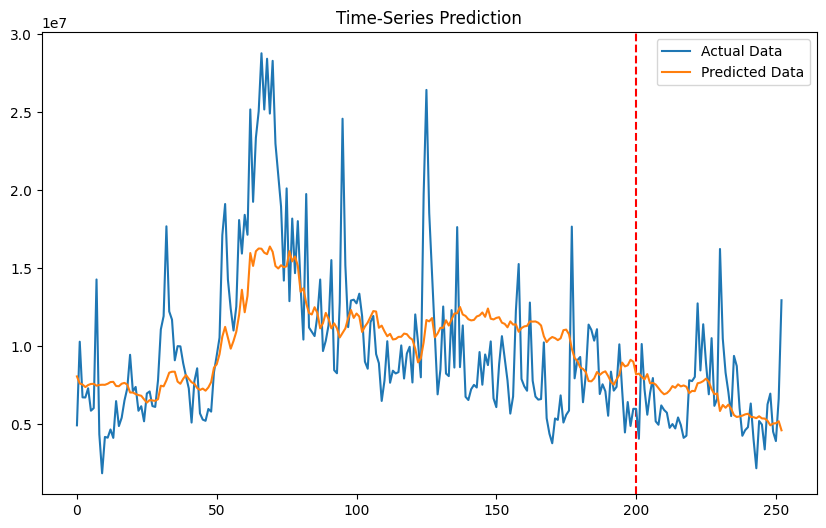

In [40]:
train_predict=model(df_x_ss)
predicted=train_predict.data.numpy()
label_y=df_y_ms.data.numpy()

predicted=ms.inverse_transform(predicted)
label_y=ms.inverse_transform(label_y)
plt.figure(figsize=(10,6))
plt.axvline(x=200,c='r',linestyle='--')
plt.plot(label_y,label='Actual Data')
plt.plot(predicted,label='Predicted Data')
plt.title('Time-Series Prediction')
plt.legend()
plt.show()